In [1]:
# Roll No: 24BAD076

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("loan.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.fillna(df.mode().iloc[0], inplace=True)

In [5]:
encoder = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = encoder.fit_transform(df[col])

In [6]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [9]:
y_pred = dt.predict(X_test)

In [10]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7479674796747967
              precision    recall  f1-score   support

           0       0.83      0.35      0.49        43
           1       0.73      0.96      0.83        80

    accuracy                           0.75       123
   macro avg       0.78      0.66      0.66       123
weighted avg       0.77      0.75      0.71       123



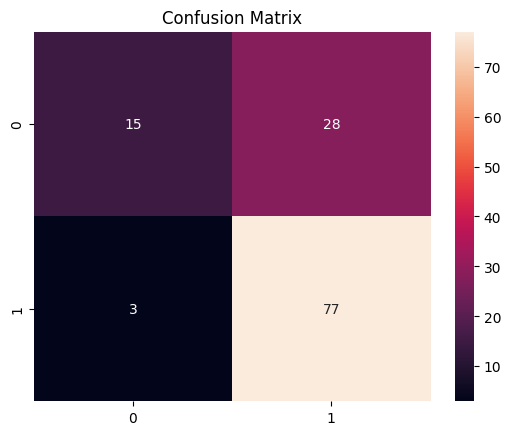

In [11]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

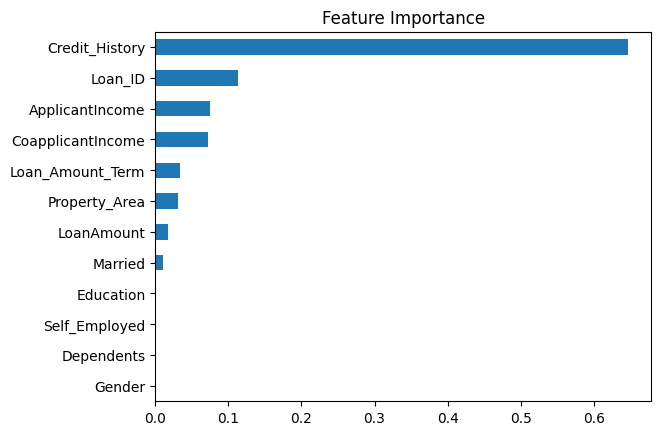

In [12]:
importance = pd.Series(dt.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

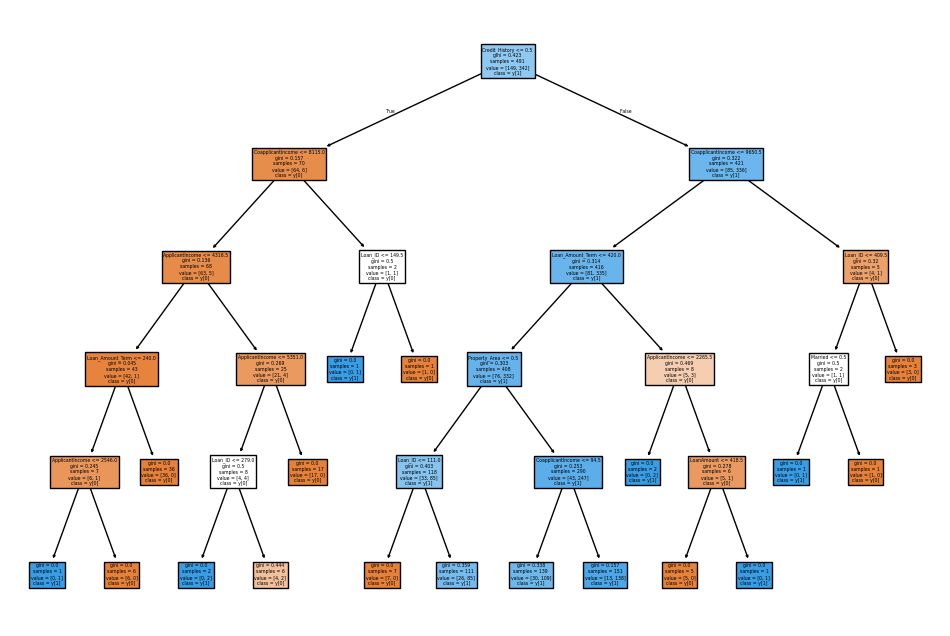

In [13]:
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=True, filled=True)
plt.show()

In [14]:
dt_deep = DecisionTreeClassifier(max_depth=None)
dt_deep.fit(X_train, y_train)

print("Shallow Tree Accuracy:", dt.score(X_test, y_test))
print("Deep Tree Accuracy:", dt_deep.score(X_test, y_test))

Shallow Tree Accuracy: 0.7479674796747967
Deep Tree Accuracy: 0.6991869918699187
